In [ ]:


import numpy as np
import matplotlib.pyplot as plt
import freud
from joint_diagonalisation import joint_diag


class PointProcess:
    def __init__(self, N=1000, name =""):
        self.N = N
        self.lambda_intensity = 1.0
        self.L = N ** (1/3)
        self.box = freud.box.Box.cube(self.L)
        self.positions = None  
        self.k = None
        self.S_k = None
        self.name = name
        self.dim = "3D" #efault behaviour

        k0 = 2 * np.pi / self.L

        n_min = 1
        n_max = 30

        self.bins = 20
        self.k_min = n_min * k0
        self.k_max = n_max * k0

    # =========================
    # Sampling
    # =========================
    def sample(self, kind="hpp", n_samples=1):
        keyword = kind.split()
        kind = keyword[0]
        self.positions = []

        for _ in range(n_samples):
            if kind == "hpp":
                N = self.N
                pts = np.random.rand(N, 3)*self.L

            elif kind == "lattice": 
                n = int(round(self.N ** (1/3)))  # points per dimension
                dx = self.L / n

                x = np.linspace(0, self.L - dx, n)
                y = np.linspace(0, self.L - dx, n)
                z = np.linspace(0, self.L - dx, n)

                X, Y, Z = np.meshgrid(x, y, z, indexing='ij')
                pts = np.vstack([X.ravel(), Y.ravel(), Z.ravel()]).T

            elif kind == "ginibre":
                #collapse z axis
                self.dim = "2D"

                N = self.N
                M = self.sample_matrix(N)
                pts2D = self.eigval_points(M)

                pts3D = np.zeros((N, 3))
                pts3D[:, :2] = pts2D

                pts = self.ball_to_square(pts3D)

            elif kind =="jointdiag":
                dim = keyword[1]
                d = int(dim[0])
                self.dim = dim

                N = self.N
                Nl = 10*N

                U = np.random.normal(size=(Nl, N))
                U = U/(np.sqrt((U**2).sum(axis=1)[:,None]))
                lambdas = 2*np.random.rand(d, Nl)-1

                Mlist = np.zeros((d, N, N))
                for i in range(d):
                    Mlist[i] = U.T @ (lambdas[i][:, None] * U)

                pts3D = np.zeros((N, 3)) 
                _, ptsND, _ =  joint_diag(Mlist)
                pts3D[:, :d] = ptsND
                pts = self.ball_to_square(pts3D)

            else:
                raise ValueError("Unknown process type")

            self.positions.append(pts)

    # =========================
    # Ginibre helpers
    # =========================
    @staticmethod
    def sample_matrix(N):
        re = np.random.normal(size=(N, N))
        im = np.random.normal(size=(N, N))
        M = re + 1j * im
        return M / np.sqrt(2 * N)

    @staticmethod
    def eigval_points(M):
        ev = np.linalg.eigvals(M)
        points = np.zeros((len(ev), 2))
        points[:, 0], points[:, 1] = ev.real, ev.imag
        return points
    
    def ball_to_square(self, pts):
        pts = (pts -pts.mean(axis=0)[None, :])/(pts.std(axis=0)[None, :] + 0.0001)
        trunc = 0.5*np.max(np.abs(pts))
        mask = (np.max(np.abs(pts), axis=1) <= trunc)
        pts = pts[mask]
        pts = ((pts + trunc)/(2*trunc))*self.L
        return pts


    # =========================
    # Structure factor (average over samples)
    # =========================
    def compute_structure_factor(self):
        if self.dim == "2D":
            self.box.Lz = self.L/(100_000)
        if self.positions is None:
            raise RuntimeError("Sample points first")
        sf = freud.diffraction.StaticStructureFactorDirect(bins = self.bins, k_min = self.k_min, k_max = self.k_max)

        for pts in self.positions:
            sf.compute((self.box, pts), reset=False)

        self.k = sf.bin_centers
        self.S_k = sf.S_k

    # =========================
    # Plot points 
    # =========================
    def plot_points(self, n_slices=9):
        if self.positions is None:
            raise RuntimeError("No points to plot")
        pts = self.positions[0]

        if self.dim == "2D":
            plt.figure(figsize = (6, 6))
            plt.scatter(pts[:, 0], pts[:, 1], s=5)
            plt.xticks([])
            plt.yticks([])
            plt.show()
            return

        bins = np.linspace(0, self.L, n_slices + 1)      

        fig, axes = plt.subplots(3, 3, figsize=(6, 6))
        axes = axes.flatten()

        for i in range(n_slices):
            z_low, z_high = bins[i], bins[i+1]

            mask = (pts[:, 2] >= z_low) & (pts[:, 2] < z_high)
            slice_pts = pts[mask]

            ax = axes[i]
            ax.scatter(slice_pts[:, 0], slice_pts[:, 1], s=5)

            ax.set_xlim(0, self.L)
            ax.set_ylim(0, self.L)
            ax.set_aspect('equal')
            for spine in ax.spines.values():
                spine.set_linewidth(0.5)
                spine.set_color("0.7") 

            ax.set_xticks([])
            ax.set_yticks([])

        plt.subplots_adjust(wspace=0, hspace=0)

        plt.show()
    # =========================
    # Plot S(k)
    # =========================
    def plot_structure_factor(self):
        if self.S_k is None:
            raise RuntimeError("Compute structure factor first")

        plt.figure()
        plt.scatter(self.k, self.S_k)
        plt.yticks([0, 1, 3])
        plt.xlabel("k")
        plt.ylabel("S(k)")
        plt.title("Structure Factor")
        plt.show()

In [71]:

# =========================
# Number of points
# =========================
N = 1000

Classical Poisson

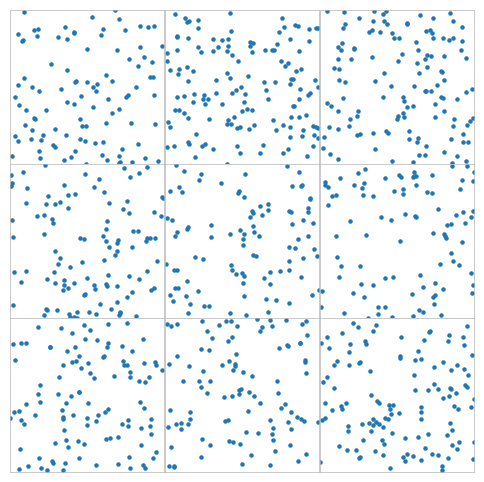

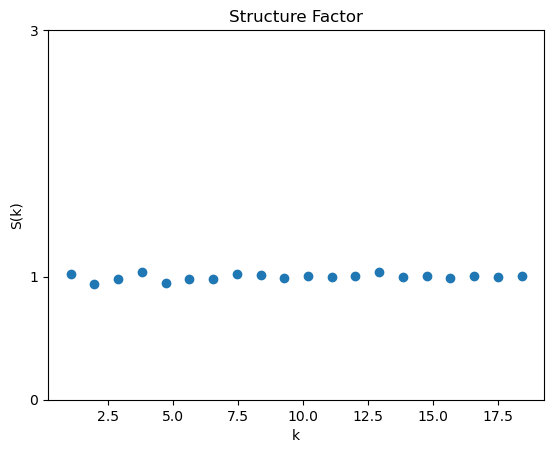

In [72]:
pp = PointProcess(N=N)
pp.sample(kind="hpp", n_samples=10)
pp.plot_points()
pp.compute_structure_factor()
pp.plot_structure_factor()

Classical Lattice

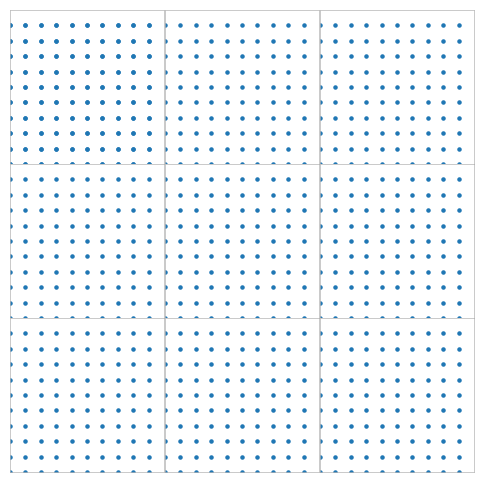

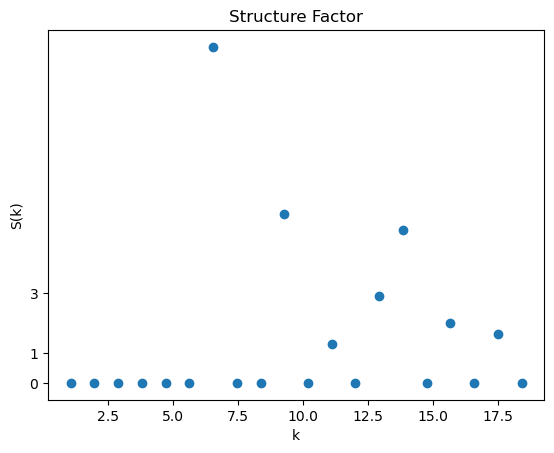

In [73]:
pp = PointProcess(N=N)
pp.sample(kind="lattice", n_samples=10)
pp.plot_points()
pp.compute_structure_factor()
pp.plot_structure_factor()

Ginibre (2D)

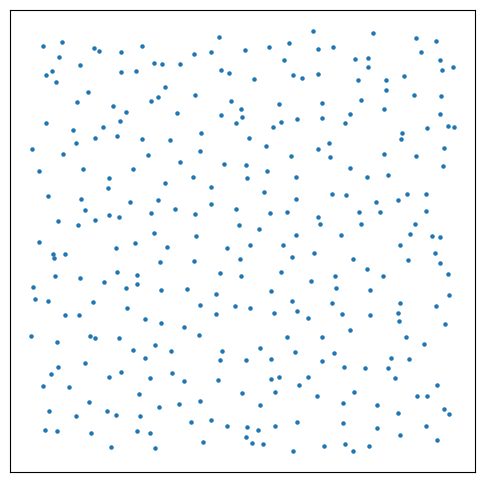

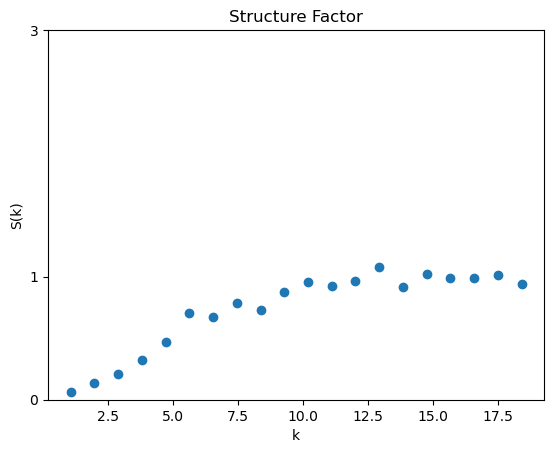

In [74]:
pp = PointProcess(N=N)
pp.sample(kind="ginibre", n_samples= 3)
pp.plot_points()
pp.compute_structure_factor()
pp.plot_structure_factor()

Joint diagonalisation (2D)

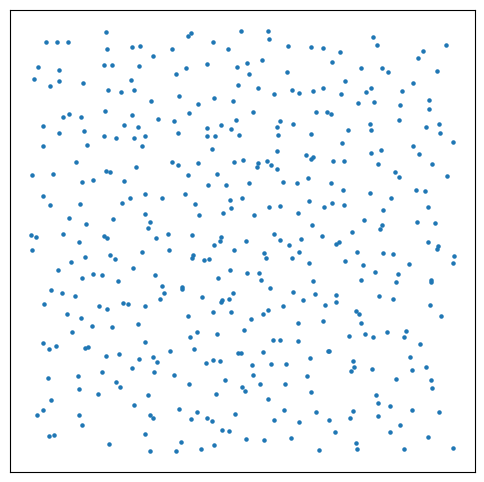

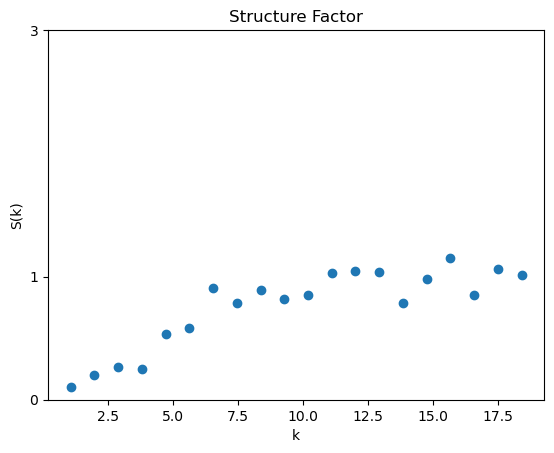

In [75]:
pp = PointProcess(N=N)
pp.sample(kind="jointdiag 2D", n_samples= 3)
pp.plot_points()
pp.compute_structure_factor()
pp.plot_structure_factor()


Joint diagonalisation kind of generalize Ginibre idea. We can compute multidimensional eigenvalue, and thus generate hpp in any dim.
Here joint diagonalisation (3D)

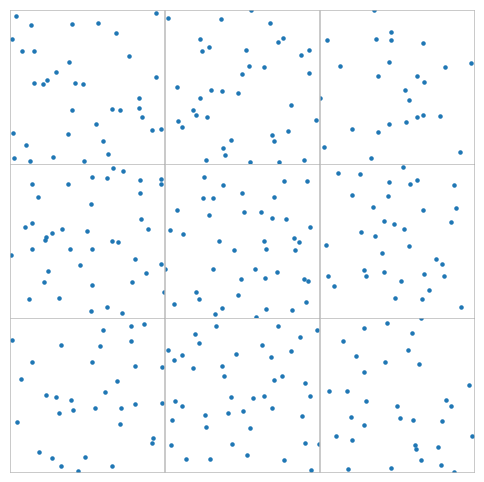

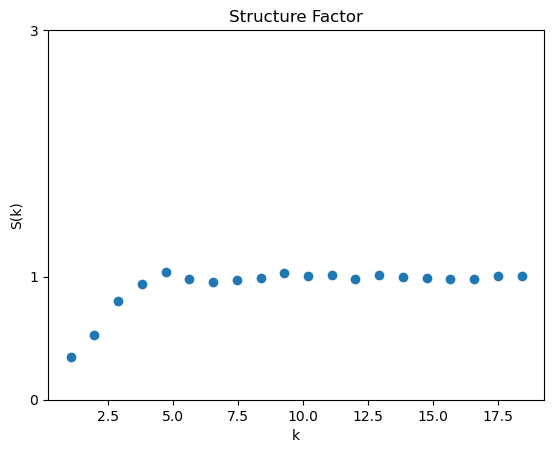

In [76]:
pp = PointProcess(N=N)
pp.sample(kind="jointdiag 3D", n_samples= 3)
pp.plot_points()
pp.compute_structure_factor()
pp.plot_structure_factor()